# ***Proyecto: Análisis de Calidad de Vinos mediante Reducción de Dimensionalidad y Clasificadores Probabilísticos***

---

* ***Autor:*** Jolehisy Acevedo Medina
* ***Fecha:*** 22/04/2026
* Informática Industrial Avanzada
* Máster en Ingeniería Industrial
* Universidad de La Laguna

---

## ***1. Descripción del Dataset***

Para esta práctica utilizaremos el conjunto de datos **"Wine Quality"**, el cual recopila información fisicoquímica de las variantes de vino tinto y blanco del ***"Vinho Verde"*** portugués. El propósito fundamental es realizar un análisis predictivo para determinar la calidad percibida del vino basándose en sus propiedades químicas.

Las variables de entrada (características) incluidas en el estudio son:

* ***Fixed acidity / Volatile acidity / Citric acid***: Ácidos orgánicos que influyen en el sabor y estabilidad del vino.
* ***Residual sugar***: Azúcar remanente tras la fermentación; factor clave para el dulzor.
* ***Chlorides***: Concentración de sales presentes.
* ***Free sulfur dioxide / Total sulfur dioxide***: Niveles de dióxido de azufre para prevenir la oxidación.
* ***Density / pH / Sulphates***: Parámetros físicos de densidad, nivel de acidez y aditivos antioxidantes.
* ***Alcohol***: Graduación alcohólica, uno de los factores más influyentes en la calidad.

La variable objetivo (***Target***) es:
* ***Quality***: Puntuación sensorial (numérica) que refleja la calidad del vino.

---

## ***2. Objetivos del Proyecto***

El objetivo de este cuaderno es desarrollar un flujo de trabajo de ***Machine Learning*** siguiendo los contenidos y cuadernos base de la asignatura:

1.  ***Análisis Exploratorio de Datos (EDA)***: Realizar un estudio detallado de las estadísticas descriptivas y una **Matriz de Correlación** para identificar qué variables químicas impactan más en la calidad.
2.  ***Preprocesamiento y Limpieza***: Identificar y gestionar valores nulos y aplicar una **Normalización de los datos**, requisito indispensable para el PCA.
3.  ***Reducción de Dimensionalidad (PCA)***: Implementar el **Análisis de Componentes Principales** para simplificar el espacio de características, justificando la varianza explicada.
4.  ***Clasificación Probabilística***: Implementar y entrenar dos modelos de clasificación basados en probabilidad.
5.  ***Evaluación de Modelos y Comparativa***: Contrastar el rendimiento de los modelos **con y sin el uso de PCA**. Se emplearán métricas como: **Matriz de Confusión**, **Precisión (Accuracy)** y **Validación Cruzada (Cross-Validation)**.

## **3. Fase 1: Procesamiento de datos**
### **3.1. Carga del dataset**
Dado que disponemos de los datos tanto para el vino tinto (**Red**) como para el blanco (**White**), procederemos a cargarlos de forma local. Para realizar un análisis global, uniremos ambos conjuntos en un único DataFrame.

**Pasos:**
1. Carga de `winequality-red.csv` y `winequality-white.csv`.
2. Creación de una columna nueva llamada `type` (1 para tinto, 0 para blanco) para que el modelo pueda distinguir el tipo de vino.
3. Concatenación de ambas tablas en una única.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los dos archivos locales
df_red = pd.read_csv('winequality-red.csv', sep=';')
df_white = pd.read_csv('winequality-white.csv', sep=';')

# 2. Añadir etiqueta para diferenciar el tipo de vino
df_red['type'] = 1   # Tinto
df_white['type'] = 0  # Blanco

# 3. Unir ambos en un solo DataFrame
df = pd.concat([df_red, df_white], axis=0, ignore_index=True)

# 4. Comprobación
print(f"Total de vinos tintos: {df_red.shape[0]}")
print(f"Total de vinos blancos: {df_white.shape[0]}")
print(f"Dataset total: {df.shape[0]} filas y {df.shape[1]} columnas.")

display(df.sample(20)) # Mostramos 20 filas al azar para ver la mezcla

Total de vinos tintos: 1599
Total de vinos blancos: 4898
Dataset total: 6497 filas y 13 columnas.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
2893,6.9,0.410,0.22,4.20,0.031,10.0,102.0,0.99300,3.00,0.86,11.6,4,0
1959,6.4,0.240,0.32,14.90,0.047,54.0,162.0,0.99680,3.28,0.50,10.2,6,0
3592,7.4,0.300,0.22,5.25,0.053,33.0,180.0,0.99260,3.13,0.45,11.6,6,0
847,7.4,0.680,0.16,1.80,0.078,12.0,39.0,0.99770,3.50,0.70,9.9,6,1
5158,7.5,0.340,0.24,3.85,0.031,5.0,34.0,0.99098,3.01,0.36,11.8,4,0
1291,8.2,0.635,0.10,2.10,0.073,25.0,60.0,0.99638,3.29,0.75,10.9,6,1
5573,6.5,0.290,0.52,7.90,0.049,35.0,192.0,0.99551,3.16,0.51,9.5,6,0
4538,7.0,0.120,0.29,10.30,0.039,41.0,98.0,0.99564,3.19,0.38,9.8,8,0
6390,6.7,0.300,0.50,12.10,0.045,38.0,127.0,0.99740,3.04,0.53,8.9,6,0
713,8.0,0.430,0.36,2.30,0.075,10.0,48.0,0.99760,3.34,0.46,9.4,5,1


### 3.2. Análisis de la Calidad según el Tipo de Vino

Antes de profundizar en la química, analizamos cómo se distribuyen las puntuaciones de calidad entre ambos tipos. El objetivo es comprobar si la métrica de calidad (0-10) es consistente o si un tipo de vino tiende a recibir mejores valoraciones que el otro.

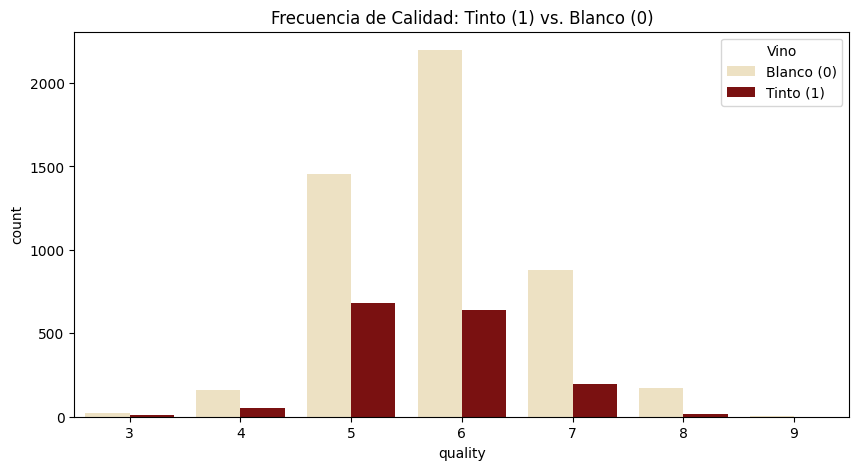

Media de calidad por tipo:
type
0    5.877909
1    5.636023
Name: quality, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(x='quality', hue='type', data=df, palette={1: '#8b0000', 0: '#f4e4bc'})
plt.title('Frecuencia de Calidad: Tinto (1) vs. Blanco (0)')
plt.legend(title='Vino', labels=['Blanco (0)', 'Tinto (1)'])
plt.show()

print("Media de calidad por tipo:")
print(df.groupby('type')['quality'].mean())

***Análisis de los resultados (Punto 3.2):***


Tras observar la distribución de la calidad según el tipo de vino, podemos extraer tres conclusiones clave:

1. **Predominio de Calidades Medias:** Tanto en el vino tinto como en el blanco, la inmensa mayoría de las muestras se concentran en las puntuaciones **5 y 6**.
2. **Desbalance de Clases:** Existe una diferencia notable en el volumen de datos; hay significativamente **más registros de vino blanco** que de tinto. Este factor es crucial para el entrenamiento de los clasificadores probabilísticos, ya que el modelo podría tener un mejor rendimiento prediciendo la calidad de blancos debido a la mayor cantidad de ejemplos.
3. **Consistencia en la Evaluación:** A pesar de las diferencias químicas, la **calidad media es muy similar** en ambos tipos (rondando el 5.6 - 5.8). Esto sugiere que los criterios de calidad sensorial son consistentes, independientemente de si el vino es tinto o blanco.

### 3.3. Análisis Global de las Características vs. Calidad

Para comprender cómo influyen los componentes químicos en la valoración del vino, generaremos un panel de visualización. Utilizaremos **Diagramas de Caja (Boxplots)** para las 12 variables del dataset (las 11 fisicoquímicas originales y la variable de tipo).

Este análisis nos permite:
1. **Identificar tendencias**: Observar qué variables suben o bajan de valor a medida que aumenta la calidad.
2. **Detectar Outliers**: Ver en qué variables existen valores extremos que se salen de la norma.
3. **Evaluar la Dispersión**: Comparar si los vinos de alta calidad son más "estables" químicamente que los de baja calidad.

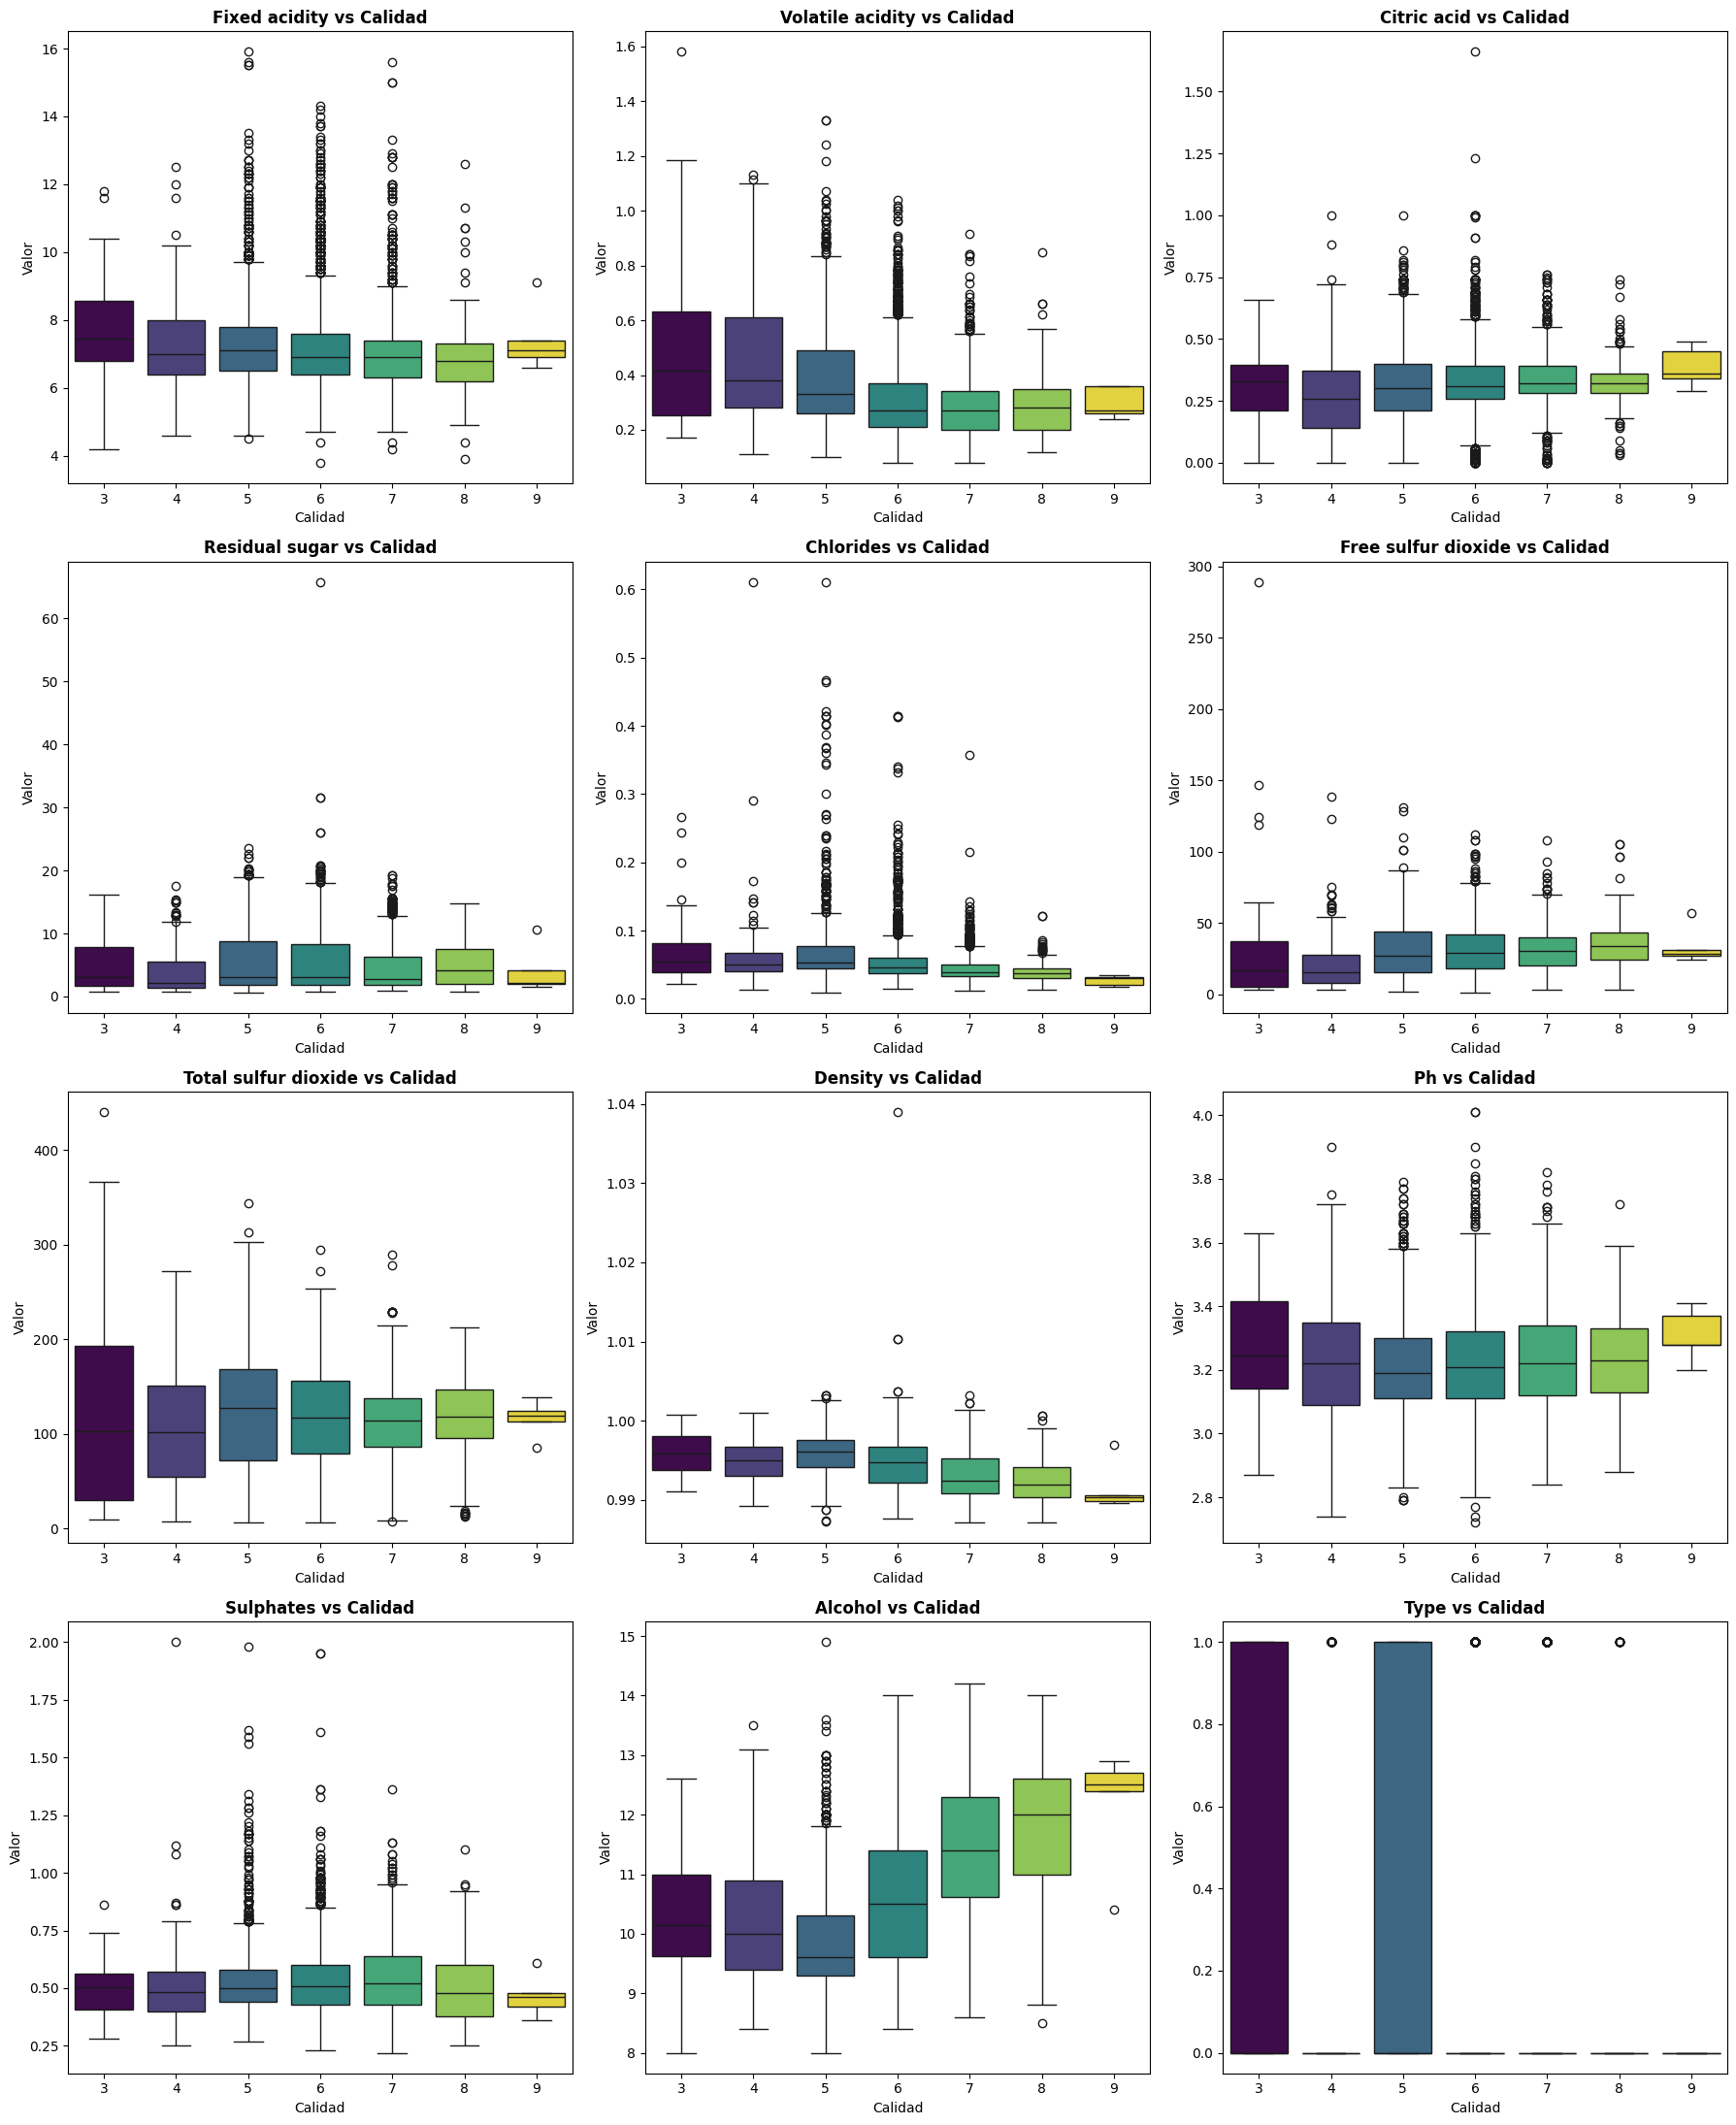

In [10]:
# Definimos las 12 variables (11 químicas + 'type')
# Quitamos 'quality' porque es nuestro eje X
features = df.columns.drop('quality')

# Configuramos la matriz de 4 filas y 3 columnas
fig, axes = plt.subplots(4, 3, figsize=(18, 22))
axes = axes.flatten()

# Iteramos para crear cada gráfico
for i, col in enumerate(features):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis', hue='quality', legend=False)
    axes[i].set_title(f'{col.replace("_", " ").capitalize()} vs Calidad', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Calidad')
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.show()

***Análisis de los resultados (Punto 3.3):***

Después de observar cómo se comportan las 12 variables respecto a la calidad, estas son las conclusiones clave:

* **Variables que mandan (Determinantes):** El **alcohol** es, sin duda, la variable más clara: a más alcohol, más calidad. También la **acidez volátil** es clave, pero al revés: cuanto menos tiene el vino, mejor puntuación recibe.
* **Variables que acompañan:** La **densidad** y los **cloruros** suelen bajar en los vinos de alta calidad. Es decir, los vinos mejores suelen ser menos "pesados" y menos salinos. El **azúcar residual** también tiende a ser más bajo en los vinos top.
* **Variables de "relleno" (Poco determinantes):** El **pH**, el **ácido cítrico** y los **sulfatos** se mueven en rangos muy parecidos para todas las calidades. No sirven para distinguir fácilmente un vino de 3 de uno de 9 porque casi todos tienen valores similares.
* **Comportamientos Curiosos:** El **dióxido de azufre** (libre y total) es muy bajo en los vinos de peor calidad (3 y 4), sube en los niveles medios y se estabiliza. Parece que un mínimo de este conservante es necesario para que el vino no sea "malo", pero no por tener más va a ser "excelente".
* **Sobre el Tipo de Vino:** La gráfica del tipo muestra que en las calidades más altas hay una mezcla, pero no es una variable que por sí sola te diga la calidad; necesitas ver el resto de la química.

**En resumen:** Para predecir la calidad, tendrá que fijarse sobre todo en el alcohol y la acidez, usando el resto de variables para ajustar.

### 3.4. Análisis de Correlación y Dependencias Funcionales

En esta sección se analiza la interacción entre las distintas dimensiones del dataset para optimizar el posterior proceso de clasificación. El estudio de la matriz de correlación y su representación mediante un mapa de calor persigue los siguientes objetivos:

1.  **Cuantificación de la Influencia sobre la Calidad:** Establecer el peso estadístico de cada variable fisicoquímica sobre la variable objetivo (`quality`). Esto permite validar numéricamente qué características presentan una mayor capacidad predictiva.
2.  **Diagnóstico de Redundancia Informativa (Multicolinealidad):** Identificar pares de variables de entrada que presentan una alta correlación entre sí. La presencia de dependencias fuertes indica que el dataset contiene información redundante, lo cual puede introducir ruido en los modelos probabilísticos.
3.  **Fundamentación de la Reducción de Dimensionalidad:** Este análisis constituye la base técnica para la aplicación del **PCA (Análisis de Componentes Principales)**. Si se detectan correlaciones elevadas, queda demostrado que es posible proyectar los datos en un espacio de menor dimensión (componentes principales) sin pérdida significativa de información, eliminando la redundancia detectada.

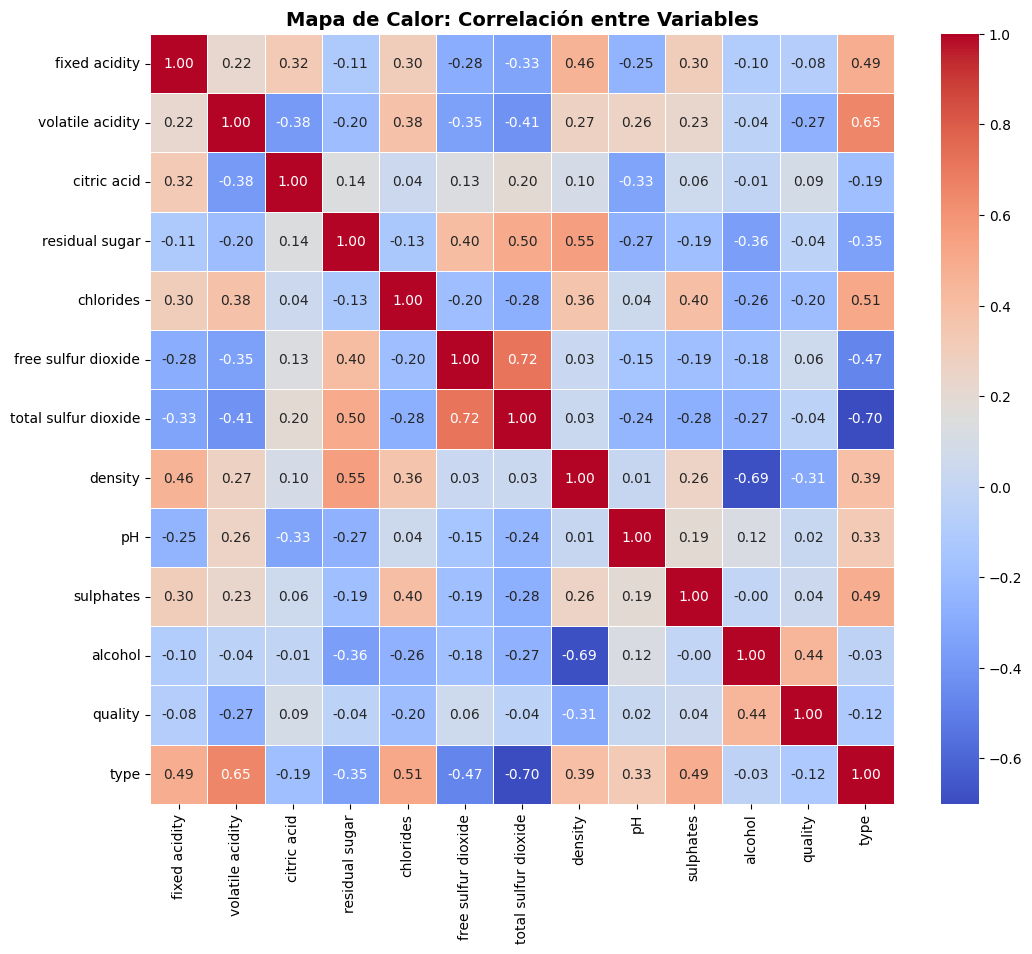

In [ ]:
# Calculamos la matriz numérica de correlación
corr_matrix = df.corr()

# Creamos el gráfico (Mapa de Calor)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Mapa de Calor: Correlación entre Variables', fontsize=14, fontweight='bold')
plt.show()

***Análisis de resultados (Punto 3.4):***

Tras observar el mapa de calor, estas son las conclusiones técnicas que definen la relación entre las variables:

* **Determinantes de Calidad:** Se confirma numéricamente que el **alcohol** (+0.44) y la **acidez volátil** (-0.39) son los factores con mayor impacto en la calidad. Es decir, a mayor graduación y menor acidez volátil, mejor es la puntuación.
* **Redundancia Informativa:** Existen correlaciones muy altas entre ciertas químicas, destacando el **dióxido de azufre libre vs. total** (+0.72) y la **densidad vs. alcohol** (-0.68). Esto indica que hay datos que "se repiten".
* **Independencia Estocástica:** Variables como el **azúcar residual** o los **sulfatos** muestran correlaciones cercanas a cero con el resto, aportando información única que no depende de los otros parámetros.